<a href="https://colab.research.google.com/github/mak-shah/COO/blob/master/Copy_of_Live_Class_Notebook_Scaling_AI_Applications.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

Sat Jul 11 15:59:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Install vLLM and lightweight analysis/client libraries.
# This can take several minutes on a fresh Colab runtime.
!pip -q install -U "vllm[bench]" openai pandas matplotlib requests transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 9.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.7/211.7 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.5/447.5 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.0/14.0 MB 97.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.8/178.8 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 97.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/

In [ ]:
# Basic import/version check.
import sys, platform, os, time, json, math, statistics, subprocess, signal, gc
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import requests

print("Python:", sys.version)
print("Platform:", platform.platform())

try:
    import torch
    print("Torch:", torch.__version__)
    print("CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
except Exception as e:
    print("Torch import failed:", repr(e))

try:
    import vllm
    print("vLLM:", vllm.__version__)
except Exception as e:
    print("vLLM import failed. Restart runtime once if this happened right after pip install.")
    print(repr(e))

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Platform: Linux-6.6.122+-x86_64-with-glibc2.35
Torch: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4
vLLM: 0.24.0


In [ ]:
MODEL = "Qwen/Qwen2.5-0.5B-Instruct" #Load the Qwen2.5 Instruct model with approximately 0.5 billion parameters.
DTYPE = "half"                 # safer default for T4 than bfloat16
MAX_MODEL_LEN = 2048            # keep small for Colab T4
GPU_MEMORY_UTILIZATION = 0.82   # leave some room for notebook + server overhead
SERVER_PORT = 8000
BASE_URL = f"http://127.0.0.1:{SERVER_PORT}"

print("MODEL:", MODEL)
print("BASE_URL:", BASE_URL)

MODEL: Qwen/Qwen2.5-0.5B-Instruct
BASE_URL: http://127.0.0.1:8000


In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL)
def count_tokens(text: str) -> int:
    return len(tokenizer.encode(text, add_special_tokens=False))


def percentile(values, q):
    values = [v for v in values if v is not None and not pd.isna(v)]
    if not values:
        return None
    return float(pd.Series(values).quantile(q / 100.0))


def summarize_latency_df(df, latency_col="e2e_s"):
    return pd.DataFrame([{
        "count": len(df),
        "mean_s": df[latency_col].mean(),
        "p50_s": df[latency_col].quantile(0.50),
        "p90_s": df[latency_col].quantile(0.90),
        "p95_s": df[latency_col].quantile(0.95),
        "p99_s": df[latency_col].quantile(0.99),
        "min_s": df[latency_col].min(),
        "max_s": df[latency_col].max(),
    }])


def plot_bar(df, x, y, title, ylabel=None):
    ax = df.plot(kind="bar", x=x, y=y, legend=False, figsize=(8, 4))
    ax.set_title(title)
    ax.set_ylabel(ylabel or y)
    ax.set_xlabel(x)
    plt.xticks(rotation=0)
    plt.show()


def plot_line(df, x, ys, title):
    ax = df.plot(x=x, y=ys, marker="o", figsize=(8, 4))
    ax.set_title(title)
    ax.set_xlabel(x)
    plt.grid(True)
    plt.show()

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
from vllm import LLM, SamplingParams

sampling_params = SamplingParams(
    temperature=0.2,
    top_p=0.95, # choose top 5% of tokens with high probability, then sample -wrong
    max_tokens=64,
)

llm = LLM(
    model=MODEL,
    dtype=DTYPE,
    max_model_len=MAX_MODEL_LEN,
    gpu_memory_utilization=GPU_MEMORY_UTILIZATION,
    trust_remote_code=False,
)

INFO 07-11 16:30:11 [api_utils.py:273] non-default args: {'dtype': 'half', 'max_model_len': 2048, 'gpu_memory_utilization': 0.82, 'disable_log_stats': True, 'model': 'Qwen/Qwen2.5-0.5B-Instruct'}
INFO 07-11 16:30:34 [model.py:598] Resolved architecture: Qwen2ForCausalLM
WARNING 07-11 16:30:34 [model.py:2063] Casting torch.bfloat16 to torch.float16.
INFO 07-11 16:30:34 [model.py:1725] Using max model len 2048
INFO 07-11 16:30:34 [scheduler.py:252] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 07-11 16:30:34 [vllm.py:1006] Asynchronous scheduling is enabled.
INFO 07-11 16:30:34 [kernel.py:276] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'], fused_add_rms_norm=['native'])


generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

WARNING 07-11 16:30:38 [system_utils.py:157] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing for more information. Reasons: CUDA is initialized


In [ ]:
prompts = [
    "Explain latency vs throughput in LLM serving in three bullet points.",
    "Explain why P99 latency matters for production AI applications.",
]

outputs = llm.generate(prompts, sampling_params)

for out in outputs:
    print("PROMPT:", out.prompt)
    print("OUTPUT:", out.outputs[0].text.strip())
    print("-" * 80)

Rendering prompts:   0%|          | 0/2 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 2/2 [00:01<00:00,  1.11it/s, est. speed input: 15.06 toks/s, output: 71.37 toks/s]

PROMPT: Explain latency vs throughput in LLM serving in three bullet points.
OUTPUT: 1. Latency: The time it takes for a message to be processed by the server. 2. Throughput: The number of messages processed per second. 3. Latency is a measure of the time it takes for a message to be processed by the server, while throughput is the number of messages
--------------------------------------------------------------------------------
PROMPT: Explain why P99 latency matters for production AI applications.
OUTPUT: P99 latency is a critical metric for evaluating the performance of a production AI application. It refers to the average time it takes for a request to be processed by the application, and is typically measured in milliseconds. P99 latency is important for production AI applications because it indicates the average time it takes for a request
--------------------------------------------------------------------------------


In [ ]:
def make_prompt(i: int) -> str:
    topics = [
        "TTFT and streaming latency",
        "throughput vs goodput",
        "PagedAttention and KV cache",
        "tensor parallelism",
        "pipeline parallelism",
        "data parallelism",
        "P95 and P99 latency",
        "request-rate saturation",
    ]
    topic = topics[i % len(topics)]
    return f"Explain {topic} for an ML engineer in exactly four short bullet points."


def run_offline_batch(num_requests: int, max_tokens: int = 64):
    prompts = [make_prompt(i) for i in range(num_requests)]
    params = SamplingParams(temperature=0.0, max_tokens=max_tokens)

    t0 = time.perf_counter()
    outputs = llm.generate(prompts, params)
    t1 = time.perf_counter()

    input_tokens = 0
    output_tokens = 0
    for out in outputs:
        # vLLM RequestOutput usually exposes prompt_token_ids and generated token_ids.
        input_tokens += len(getattr(out, "prompt_token_ids", []) or tokenizer.encode(out.prompt, add_special_tokens=False))
        output_tokens += len(out.outputs[0].token_ids)

    wall_time = t1 - t0
    return {
        "num_requests": num_requests,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "total_tokens": input_tokens + output_tokens,
        "wall_time_s": wall_time,
        "requests_per_sec": num_requests / wall_time,
        "output_tokens_per_sec": output_tokens / wall_time,
        "total_tokens_per_sec": (input_tokens + output_tokens) / wall_time,
        "avg_e2e_per_request_s": wall_time / num_requests,
    }

run_offline_batch(1)
run_offline_batch(4)
run_offline_batch(16)


batch_sizes = [1, 2, 4, 8, 16, 32]
offline_results = []

for bs in batch_sizes:
    print(f"Running batch size {bs}...")
    offline_results.append(run_offline_batch(bs, max_tokens=64))

offline_df = pd.DataFrame(offline_results)
offline_df

Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 1/1 [00:00<00:00,  2.15it/s, est. speed input: 38.92 toks/s, output: 138.38 toks/s]


Rendering prompts:   0%|          | 0/4 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 4/4 [00:00<00:00,  9.84it/s, est. speed input: 172.61 toks/s, output: 631.26 toks/s]


Rendering prompts:   0%|          | 0/16 [00:00<?, ?it/s]

...

Processed prompts: 100%|██████████| 16/16 [00:00<00:00, 33.19it/s, est. speed input: 577.91 toks/s, output: 2128.70 toks/s]

Running batch size 32...


Rendering prompts:   0%|          | 0/32 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 32/32 [00:00<00:00, 56.40it/s, est. speed input: 981.77 toks/s, output: 3616.26 toks/s]


,num_requests,input_tokens,output_tokens,total_tokens,wall_time_s,requests_per_sec,output_tokens_per_sec,total_tokens_per_sec,avg_e2e_per_request_s
0,1,18,64,82,0.407946,2.451306,156.883564,201.007066,0.407946
1,2,35,128,163,0.396919,5.038813,322.484002,410.663222,0.198459
2,4,70,256,326,0.431311,9.274040,593.538586,755.834293,0.107828
3,8,139,512,651,0.480940,16.634100,1064.582387,1353.599871,0.060117
4,16,278,1024,1302,0.543203,29.454933,1885.115720,2396.895183,0.033950
5,32,556,2048,2604,0.609350,52.514933,3360.955707,4273.402666,0.019042


In [ ]:
try:
    del llm
except NameError:
    pass

gc.collect()
try:
    import torch
    torch.cuda.empty_cache()
except Exception:
    pass

print("Cleaned offline vLLM object. Now start the local server.")

WARNING 07-11 16:51:35 [utils.py:620] [shutdown] Process manager: force killing remaining processes count=1
Cleaned offline vLLM object. Now start the local server.


In [ ]:
!nvidia-smi

Sat Jul 11 16:51:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   73C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
def stop_vllm_server():
    global server_process
    if "server_process" in globals() and server_process is not None:
        if server_process.poll() is None:
            print("Stopping existing vLLM server...")
            try:
                os.killpg(os.getpgid(server_process.pid), signal.SIGTERM)
            except Exception:
                server_process.terminate()
            time.sleep(3)
        server_process = None


def is_server_ready(base_url=BASE_URL):
    try:
        r = requests.get(f"{base_url}/v1/models", timeout=2)
        return r.status_code == 200
    except Exception:
        return False


def tail_file(path="vllm_server.log", n=80):
    p = Path(path)
    if not p.exists():
        print(f"{path} does not exist yet.")
        return
    lines = p.read_text(errors="ignore").splitlines()
    print("\n".join(lines[-n:]))


def wait_for_server(base_url=BASE_URL, timeout_s=240):
    start = time.time()
    while time.time() - start < timeout_s:
        if is_server_ready(base_url):
            return True
        if "server_process" in globals() and server_process is not None and server_process.poll() is not None:
            print("Server exited early. Last log lines:")
            tail_file("vllm_server.log", n=80)
            return False
        time.sleep(2)
    print("Server did not become ready within timeout. Last log lines:")
    tail_file("vllm_server.log", n=80)
    return False

stop_vllm_server()

log_file = open("vllm_server.log", "w")
cmd = [
    "vllm", "serve", MODEL,
    "--dtype", DTYPE,
    "--max-model-len", str(MAX_MODEL_LEN),
    "--gpu-memory-utilization", str(GPU_MEMORY_UTILIZATION),
    "--host", "0.0.0.0",
    "--port", str(SERVER_PORT),
    "--generation-config", "vllm",
]

print("Starting server:")
print(" ".join(cmd))

server_process = subprocess.Popen(
    cmd,
    stdout=log_file,
    stderr=subprocess.STDOUT,
    start_new_session=True,
)

ready = wait_for_server()
print("Server ready:", ready)

Starting server:
vllm serve Qwen/Qwen2.5-0.5B-Instruct --dtype half --max-model-len 2048 --gpu-memory-utilization 0.82 --host 0.0.0.0 --port 8000 --generation-config vllm
Server ready: True


vllm serve Qwen/Qwen2.5-0.5B-Instruct --dtype half --max-model-len 2048 --gpu-memory-utilization 0.82 --host 0.0.0.0 --port 8000 --generation-config vllm



In [ ]:
# Inspect server logs if needed.
!tail -n 40 vllm_server.log

(EngineCore pid=14179) INFO 07-11 16:56:52 [vllm.py:1006] Asynchronous scheduling is enabled.
(EngineCore pid=14179) INFO 07-11 16:56:52 [kernel.py:276] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'], fused_add_rms_norm=['native'])
(APIServer pid=14012) INFO 07-11 16:56:52 [api_server.py:577] Supported tasks: ['generate']
(APIServer pid=14012) INFO 07-11 16:56:54 [hf.py:548] Detected the chat template content format to be 'string'. You can set `--chat-template-content-format` to override this.
(APIServer pid=14012) INFO 07-11 16:56:54 [api_server.py:581] Starting vLLM server on http://0.0.0.0:8000
(APIServer pid=14012) INFO 07-11 16:56:54 [launcher.py:37] Available routes are:
(APIServer pid=14012) INFO 07-11 16:56:54 [launcher.py:46] Route: /openapi.json, Methods: GET, HEAD
(APIServer pid=14012) INFO 07-11 16:56:54 [launcher.py:46] Route: /docs, Methods: GET, HEAD
(APIServer pid=14012) INFO 07-11 16:56:54 [launcher.py:46] Route: /docs/oaut

In [ ]:
!nvidia-smi


Sat Jul 11 17:03:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   69C    P0             32W /   70W |   12553MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
MODEL

'Qwen/Qwen2.5-0.5B-Instruct'

In [ ]:
from openai import OpenAI

client = OpenAI(
    base_url=f"{BASE_URL}/v1",
    api_key="EMPTY",  # local vLLM server does not require a real key here
)

resp = client.chat.completions.create(
    model=MODEL,
    messages=[
        {"role": "system", "content": "You are a concise ML systems instructor."},
        {"role": "user", "content": "Explain TTFT and ITL in simple terms."},
    ],
    max_tokens=80,
    temperature=0.2,
)

print(resp.choices[0].message.content)

TTFT stands for "Time to First Test," which is a method used in software testing to identify and fix bugs as soon as they are discovered. It involves running a test suite on the software under test (SUT) and stopping the test execution as soon as a bug is found. This approach helps in identifying issues early, reducing the time required to fix them, and improving the overall efficiency of


In [ ]:
def stream_once(
    prompt: str,
    max_tokens: int = 96,
    temperature: float = 0.0,
):
    # Record when the request starts.
    t_start = time.perf_counter()

    # Store the arrival time of each non-empty streamed chunk.
    chunk_times = []

    # Store the text content received from each chunk.
    text_parts = []

    # Send a streaming chat-completion request to the local vLLM server.
    stream = client.chat.completions.create(
        model=MODEL,
        messages=[
            {
                "role": "user",
                "content": prompt,
            }
        ],
        max_tokens=max_tokens,
        temperature=temperature,
        stream=True,
    )

    # Read the streamed response one chunk at a time.
    for chunk in stream:
        # A streamed chunk may contain metadata without any text.
        delta = chunk.choices[0].delta.content or ""

        if delta:
            # Record when this text chunk arrived.
            now = time.perf_counter()
            chunk_times.append(now)

            # Store the generated text so the final response can be reconstructed.
            text_parts.append(delta)

    # Record when the complete streamed response finishes.
    t_end = time.perf_counter()

    # Combine all streamed text fragments into one response.
    text = "".join(text_parts)

    # Count how many tokens were generated in the final response.
    output_tokens = count_tokens(text)

    # Time to first token/chunk:
    # first chunk arrival time - request start time.
    ttft = (
        chunk_times[0] - t_start
        if chunk_times
        else None
    )

    # Calculate the time gaps between consecutive streamed chunks.
    #
    # Example:
    # chunk_times = [1.0, 1.1, 1.25]
    # gaps = [0.1, 0.15]
    gaps = [
        later_time - earlier_time
        for earlier_time, later_time
        in zip(chunk_times[:-1], chunk_times[1:])
    ]

    # Average time between streamed chunks.
    mean_itl = statistics.mean(gaps) if gaps else None

    # P95 chunk gap:
    # approximately 95% of chunk gaps were at or below this value.
    p95_itl = percentile(gaps, 95) if gaps else None

    # End-to-end latency:
    # total time from sending the request until the response completes.
    e2e = t_end - t_start

    # Approximate time per output token.
    #
    # max(output_tokens, 1) prevents division by zero
    # if the model produces no text.
    tpot = e2e / max(output_tokens, 1)

    # Return both the generated text and the measured performance metrics.
    return {
        "prompt_tokens": count_tokens(prompt),
        "output_tokens": output_tokens,
        "chunks": len(chunk_times),
        "ttft_s": ttft,
        "mean_chunk_itl_s": mean_itl,
        "p95_chunk_itl_s": p95_itl,
        "tpot_s": tpot,
        "e2e_s": e2e,
        "text": text,
    }


# Run one example streaming request.
example = stream_once(
    "Explain why P95 latency matters more than average latency in LLM serving.",
    max_tokens=96,
)

# Display only the performance metrics, excluding the generated text.
{
    key: value
    for key, value in example.items()
    if key != "text"
}

{'prompt_tokens': 17,
 'output_tokens': 96,
 'chunks': 93,
 'ttft_s': 0.08583510199969169,
 'mean_chunk_itl_s': 0.006840890532608366,
 'p95_chunk_itl_s': 0.009444088199643376,
 'tpot_s': 0.007452333541664302,
 'e2e_s': 0.715424019999773}

In [ ]:
!vllm bench latency \
  --model {MODEL} \
  --dtype {DTYPE} \
  --max-model-len {MAX_MODEL_LEN} \
  --input-len 128 \
  --output-len 64 \
  --batch-size 1 \
  --num-iters-warmup 2 \
  --num-iters 5 \
  --output-json latency_bench.json

INFO 07-11 17:10:10 [api_utils.py:273] non-default args: {'dtype': 'half', 'max_model_len': 2048, 'enable_prefix_caching': False, 'enable_lora': None, 'reasoning_parser_plugin': '', 'model': 'Qwen/Qwen2.5-0.5B-Instruct'}
INFO 07-11 17:10:10 [model.py:598] Resolved architecture: Qwen2ForCausalLM
WARNING 07-11 17:10:10 [model.py:2063] Casting torch.bfloat16 to torch.float16.
INFO 07-11 17:10:10 [model.py:1725] Using max model len 2048
INFO 07-11 17:10:10 [scheduler.py:252] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 07-11 17:10:10 [vllm.py:1006] Asynchronous scheduling is enabled.
INFO 07-11 17:10:10 [kernel.py:276] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'], fused_add_rms_norm=['native'])
(EngineCore pid=18165) INFO 07-11 17:10:48 [core.py:114] Initializing a V1 LLM engine (v0.24.0) with config: model='Qwen/Qwen2.5-0.5B-Instruct', speculative_config=None, tokenizer='Qwen/Qwen2.5-0.5B-Instruct', skip_tokenizer_init=F

In [ ]:
!nvidia-smi

Sat Jul 11 17:16:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P0             28W /   70W |   12555MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# vllm serve Qwen/Qwen2.5-7B-Instruct \
#   --dtype half \
#   --data-parallel-size 8 \
#   --port 8000

In [ ]:
import numpy as np


# 1. Original non-parallel MLP block


# X shape: 2 x 4
# 2 tokens, hidden size 4
X = np.array([
    [1, 2, 3, 4],
    [2, 0, 1, 1]
])

# W1 shape: 4 x 6
# First linear layer expands hidden size 4 -> 6
W1 = np.array([
    [1, 0, 2, 1, 1, 0],
    [0, 1, 1, 2, 0, 1],
    [1, 1, 0, 0, 2, 1],
    [0, 2, 1, 1, 0, 2]
])

# W2 shape: 6 x 4
# Second linear layer projects hidden size 6 -> 4
W2 = np.array([
    [1, 0, 1, 0],
    [0, 1, 0, 1],
    [1, 1, 0, 0],
    [0, 0, 1, 1],
    [1, 0, 0, 1],
    [0, 1, 1, 0]
])

print("X shape:", X.shape)
print("W1 shape:", W1.shape)
print("W2 shape:", W2.shape)


X shape: (2, 4)
W1 shape: (4, 6)
W2 shape: (6, 4)


In [ ]:
# Normal forward pass
Y = X @ W1

# ReLU activation
H = np.maximum(Y, 0)

Z = H @ W2

print("\n--- Normal non-parallel computation ---")
print("Y = X @ W1")
print(Y)

print("\nH = ReLU(Y)")
print(H)

print("\nZ = H @ W2")
print(Z)


--- Normal non-parallel computation ---
Y = X @ W1
[[ 4 13  8  9  7 13]
 [ 3  3  5  3  4  3]]

H = ReLU(Y)
[[ 4 13  8  9  7 13]
 [ 3  3  5  3  4  3]]

Z = H @ W2
[[19 34 26 29]
 [12 11  9 10]]


In [ ]:
# 2. Tensor Parallelism: Column parallelism for W1


# Split W1 by columns
# W1 shape: 4 x 6
# GPU 0 gets columns 0, 1, 2
# GPU 1 gets columns 3, 4, 5

W1_gpu0 = W1[:, :3]
W1_gpu1 = W1[:, 3:]

print("Original W1 shape:", W1.shape)
print("Original W1:")
print(W1)

print("\n--- W1 split by columns ---")
print("W1_gpu0 shape:", W1_gpu0.shape)
print(W1_gpu0)

print("\nW1_gpu1 shape:", W1_gpu1.shape)
print(W1_gpu1)

Original W1 shape: (4, 6)
Original W1:
[[1 0 2 1 1 0]
 [0 1 1 2 0 1]
 [1 1 0 0 2 1]
 [0 2 1 1 0 2]]

--- W1 split by columns ---
W1_gpu0 shape: (4, 3)
[[1 0 2]
 [0 1 1]
 [1 1 0]
 [0 2 1]]

W1_gpu1 shape: (4, 3)
[[1 1 0]
 [2 0 1]
 [0 2 1]
 [1 0 2]]


In [ ]:
# Both GPUs receive the same X
Y_gpu0 = X @ W1_gpu0
Y_gpu1 = X @ W1_gpu1

print("\n--- Column-parallel Linear 1 ---")
print("Y_gpu0 = X @ W1_gpu0")
print(Y_gpu0)

print("\nY_gpu1 = X @ W1_gpu1")
print(Y_gpu1)


--- Column-parallel Linear 1 ---
Y_gpu0 = X @ W1_gpu0
[[ 4 13  8]
 [ 3  3  5]]

Y_gpu1 = X @ W1_gpu1
[[ 9  7 13]
 [ 3  4  3]]


In [ ]:

# Logical full Y is concatenation of both GPU outputs
Y_from_tensor_parallel = np.concatenate([Y_gpu0, Y_gpu1], axis=1)

print("\nY reconstructed by concatenating GPU outputs")
print(Y_from_tensor_parallel)

print("\nDoes reconstructed Y match normal Y?")
print(np.array_equal(Y_from_tensor_parallel, Y))


Y reconstructed by concatenating GPU outputs
[[ 4 13  8  9  7 13]
 [ 3  3  5  3  4  3]]

Does reconstructed Y match normal Y?
True


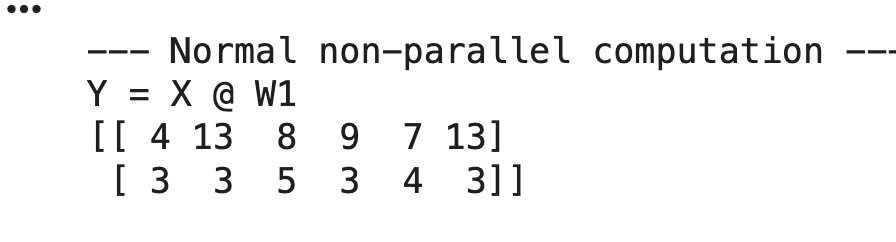

In [ ]:
# vllm serve /path/to/model \
#   --tensor-parallel-size 8 \ # it'll divide model into 8 parts, for each gpu, here 8 corresponds no of gpu available.